# Automatic Coarsening Test

Test de coarsening automatique à partir d'un maillage Telemac.

Version actuelle : pas de `res`, pas de `h_initial`. Les berges / digues / remblais sont approximés uniquement par les ruptures topographiques.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from matplotlib.collections import LineCollection

def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'python' / 'simple_transfer_coarsening.py').exists():
            return path
    raise RuntimeError('Cannot find gnn_modulus_test project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from python.python_code.data_manip.formats.serafin_file import SerafinFile
from python.simple_transfer_coarsening import (
    NORMAL,
    PRESCRIBED_H,
    PRESCRIBED_Q,
    WALL_BOUNDARY,
    build_simple_coarse_mesh,
    get_preserve_node_mask,
    get_topo_barrier_node_mask,
    mesh_scale_stats,
    unique_edges_from_triangles,
    write_coarse_bin
)

PROJECT_ROOT

PosixPath('/users/m24046/m24046mrcr/gnn_modulus_test')

In [2]:
!ls /work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5

08_T2V6_KV4_Busev2_Q5.res     T2_s08_Q5.sh  out_fortran
Maille_T2V6_BuseV3.txt	      cas	    slurm-15050426.out
Sarce_PriseLac_Q5_V1.sources  cas.conlim    slurm-15051589.out
T2V6_KV4_BuseV2.geo	      condInit.ser
T2_Q5_V1.liq		      fortran.f


## 1. Paramètres

In [3]:
# À remplir.
MESH_SLF = '/work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5/T2V6_KV4_BuseV2.geo'  
CLI_FILE = '/work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5/cas.conlim'  

# Coarsening.
SPACING = 80.0
PRESERVE_EXPAND = 1

# Laisser None pour utiliser les seuils automatiques par quantile.
DZ_MIN = None
SLOPE_MIN = None

# Visualisation.
MAX_SCATTER_POINTS = 250_000
MAX_EDGES_TO_DRAW = 80_000

# Export coarse mesh.
COARSE_BIN = '/work/m24046/m24046mrcr/Aube/automatic_coarse_mesh_T2.bin'


## 2. Utilitaires

In [4]:
def require_path(path_like: str, name: str) -> Path:
    if not path_like:
        raise ValueError(f'{name} is empty. Fill it in the parameter cell.')
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f'{name} does not exist: {path}')
    return path


def read_first_available(telemac: TelemacFile, names: list[str], timestep: int = 0):
    last_error = None
    for name in names:
        try:
            return telemac.get_data_value(name, timestep)
        except Exception as exc:
            last_error = exc
    raise KeyError(f'None of these variables were found: {names}') from last_error


def extract_boundary_type(telemac_with_cli: TelemacFile) -> np.ndarray:
    """Return integer node types: 0 normal, 1 H, 2 Q, 3 wall."""
    n_points = telemac_with_cli.tri.x.shape[0]
    boundary_type = np.zeros(n_points, dtype=np.int64)
    nbor, lihbor, liubor, livbor, _ = telemac_with_cli.get_bnd_info()

    code_to_type = {
        (5, 4, 4): PRESCRIBED_H,
        (4, 5, 5): PRESCRIBED_Q,
        (2, 2, 2): WALL_BOUNDARY,
    }

    unknown_codes = {}
    for node, lh, lu, lv in zip(nbor, lihbor, liubor, livbor):
        code = (int(lh), int(lu), int(lv))
        node_type = code_to_type.get(code)
        if node_type is None:
            unknown_codes[code] = unknown_codes.get(code, 0) + 1
            continue
        boundary_type[int(node)] = node_type

    if unknown_codes:
        print('Unknown boundary codes left as NORMAL:', unknown_codes)

    return boundary_type


def sample_indices(n: int, max_points: int) -> np.ndarray:
    if n <= max_points:
        return np.arange(n)
    rng = np.random.default_rng(0)
    return rng.choice(n, size=max_points, replace=False)


def plot_node_mask(xy, mask, title, max_points=MAX_SCATTER_POINTS):
    idx = sample_indices(len(xy), max_points)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(xy[idx, 0], xy[idx, 1], s=0.15, c='lightgray', label='fine nodes')
    ax.scatter(xy[mask, 0], xy[mask, 1], s=1.5, c='red', label='mask')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | selected={int(mask.sum())}')
    ax.legend(loc='best')
    plt.show()


def plot_edges(ax, xy, edges, color='black', linewidth=0.2, alpha=0.4, max_edges=MAX_EDGES_TO_DRAW):
    if len(edges) == 0:
        return
    idx = sample_indices(len(edges), max_edges)
    segments = xy[edges[idx]]
    lc = LineCollection(segments, colors=color, linewidths=linewidth, alpha=alpha)
    ax.add_collection(lc)


def plot_coarse_support(fine_xy, coarse_xy, coarse_edges, title='coarse support'):
    idx = sample_indices(len(fine_xy), MAX_SCATTER_POINTS)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(fine_xy[idx, 0], fine_xy[idx, 1], s=0.08, c='lightgray', label='fine nodes')
    plot_edges(ax, coarse_xy, coarse_edges, color='tab:blue', linewidth=0.35, alpha=0.55)
    ax.scatter(coarse_xy[:, 0], coarse_xy[:, 1], s=1.0, c='black', label='coarse nodes')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend(loc='best')
    plt.show()


def plot_regions(xy, labels, title, max_points=MAX_SCATTER_POINTS):
    idx = sample_indices(len(xy), max_points)
    fig, ax = plt.subplots(figsize=(10, 10))
    sc = ax.scatter(xy[idx, 0], xy[idx, 1], c=labels[idx], s=0.25, cmap='tab20')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | regions={len(np.unique(labels))}')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    plt.show()


def plot_coarse_triangulation(coarse_xy, coarse_triangles, title='coarse Delaunay triangulation'):
    fig, ax = plt.subplots(figsize=(10, 10))
    if len(coarse_triangles) > 0:
        triang = mtri.Triangulation(coarse_xy[:, 0], coarse_xy[:, 1], coarse_triangles)
        ax.triplot(triang, color='tab:blue', linewidth=0.35, alpha=0.7)
    ax.scatter(coarse_xy[:, 0], coarse_xy[:, 1], s=1.0, c='black')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | triangles={len(coarse_triangles)}')
    plt.show()


def write_coarse_slf(output_path, coarse, overwrite=True):
    """Write the coarse support as a simple SERAFIN .slf file."""
    output_path = Path(output_path).expanduser()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        if not overwrite:
            raise FileExistsError(f'Output already exists: {output_path}')
        output_path.unlink()

    coarse_xy = np.asarray(coarse.xy, dtype=np.float64)
    coarse_triangles = np.asarray(coarse.triangles, dtype=np.int32)
    coarse_z = np.asarray(coarse.z, dtype=np.float64)

    if coarse.strickler is None:
        coarse_strickler = np.zeros(len(coarse_xy), dtype=np.float64)
        print('coarse.strickler is None: writing FROTTEMENT=0.0')
    else:
        coarse_strickler = np.asarray(coarse.strickler, dtype=np.float64)

    if len(coarse_triangles) == 0:
        raise ValueError('Cannot write .slf without triangles.')

    variable_names = ['FOND', 'FROTTEMENT']
    variable_units = ['M', '']
    variable_values = [coarse_z, coarse_strickler]

    slf = SerafinFile(str(output_path), 'SERAFIN', access='w')
    slf.set_header(
        title='COARSE MESH',
        nvar=len(variable_names),
        var_name=variable_names,
        var_unit=variable_units,
    )

    ipobo = np.full(len(coarse_xy), -1, dtype=np.int32)
    knolg = np.arange(len(coarse_xy), dtype=np.int32)
    slf.set_mesh(
        mesh_dim=2,
        typ_elem=None,
        ndp=3,
        nptfr=0,
        nptir=0,
        nelem=len(coarse_triangles),
        npoin=len(coarse_xy),
        ikles=coarse_triangles,
        ipobo=ipobo,
        knolg=knolg,
        coordx=coarse_xy[:, 0],
        coordy=coarse_xy[:, 1],
        nplan=1,
        date=[2026, 4, 20],
        time=[0, 0, 0],
        x_orig=0,
        y_orig=0,
    )

    for i, (name, unit, values) in enumerate(zip(variable_names, variable_units, variable_values)):
        slf.add_data(name, unit, time=0.0, record=0, first_var=(i == 0), values=values)

    slf.close()
    return output_path

## 3. Chargement du maillage et du CLI

In [5]:
mesh_path = require_path(MESH_SLF, 'MESH_SLF')
cli_path = require_path(CLI_FILE, 'CLI_FILE')

mesh = TelemacFile(str(mesh_path))
mesh_with_cli = TelemacFile(str(mesh_path), bnd_file=str(cli_path))

xy = np.column_stack([mesh.tri.x, mesh.tri.y])
triangles = np.asarray(mesh.tri.triangles, dtype=np.int64)
z = read_first_available(mesh, ['FOND', 'BOTTOM'], timestep=0).astype(np.float64)

try:
    strickler = read_first_available(mesh, ['FROTTEMENT', 'FRICTION', 'STRICKLER'], timestep=0).astype(np.float64)
except KeyError:
    strickler = None
    print('No friction/Strickler variable found; strickler=None')

boundary_type = extract_boundary_type(mesh_with_cli)

print('nodes:', len(xy))
print('triangles:', len(triangles))
print('z:', z.shape, float(np.nanmin(z)), float(np.nanmax(z)))
print('boundary_type counts:', dict(zip(*np.unique(boundary_type, return_counts=True))))

nodes: 313521
triangles: 623905
z: (313521,) 112.86008810522175 244.60697543121677
boundary_type counts: {0: 310312, 1: 100, 2: 10, 3: 3099}


## 4. Maillage fin

fine_edges: (937462, 2)


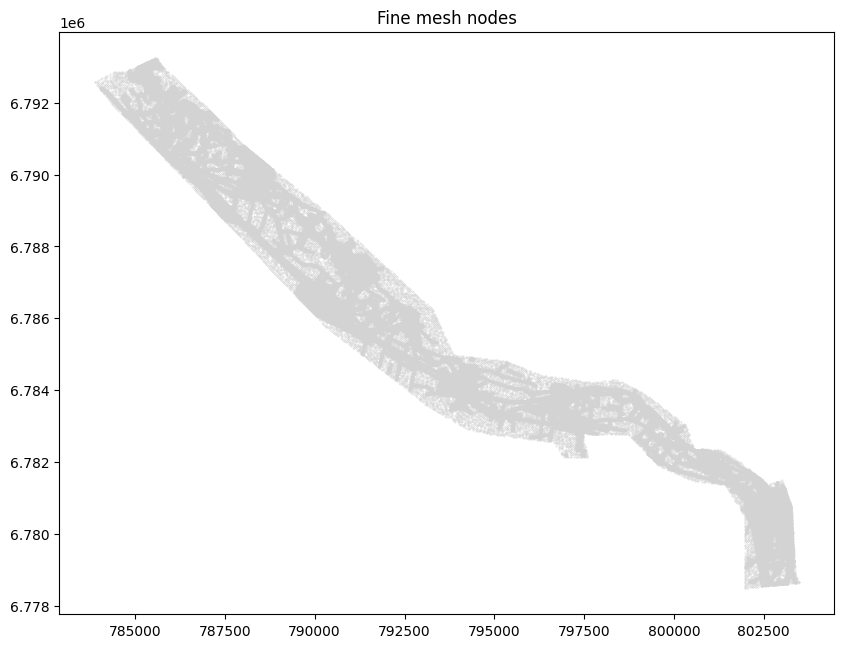

In [6]:
fine_edges = unique_edges_from_triangles(triangles)
print('fine_edges:', fine_edges.shape)

fig, ax = plt.subplots(figsize=(10, 10))
idx = sample_indices(len(xy), MAX_SCATTER_POINTS)
ax.scatter(xy[idx, 0], xy[idx, 1], s=0.1, c='lightgray')
ax.set_aspect('equal')
ax.set_title('Fine mesh nodes')
plt.show()

## 5. Étape topo_barrier_node_mask

used_dz_min: 2.2267563926079452
used_slope_min: 0.39153152915302086
topo_edge_mask edges: 6404


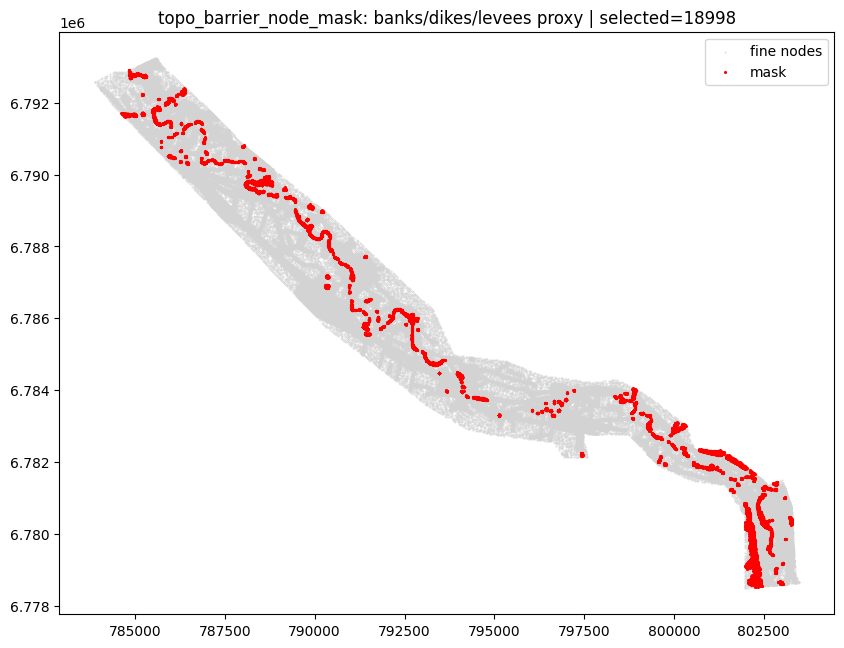

In [7]:
topo_barrier_node_mask, topo_edge_mask, used_dz_min, used_slope_min = get_topo_barrier_node_mask(
    xy=xy,
    edges=fine_edges,
    z=z,
    dz_min=DZ_MIN,
    slope_min=SLOPE_MIN,
    expand=PRESERVE_EXPAND,
)

print('used_dz_min:', used_dz_min)
print('used_slope_min:', used_slope_min)
print('topo_edge_mask edges:', int(topo_edge_mask.sum()))

plot_node_mask(xy, topo_barrier_node_mask, 'topo_barrier_node_mask: banks/dikes/levees proxy')

## 6. Étape preserve_node_mask

boundary nodes: 3209
topo barrier nodes: 18998
preserved nodes: 110


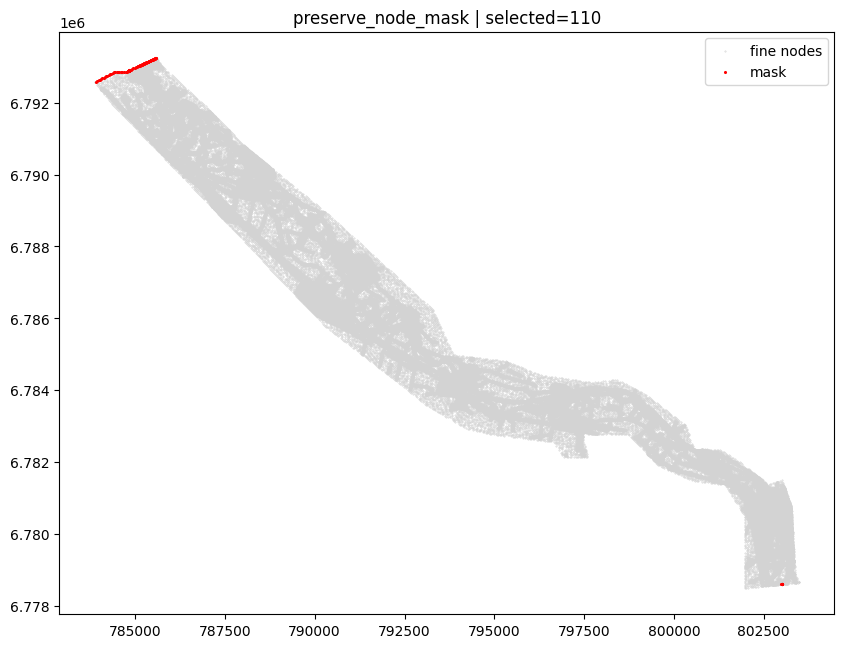

In [8]:
preserve_node_mask = get_preserve_node_mask(
    boundary_type=boundary_type,
    topo_barrier_node_mask=topo_barrier_node_mask,
)

print('boundary nodes:', int((boundary_type != NORMAL).sum()))
print('topo barrier nodes:', int(topo_barrier_node_mask.sum()))
print('preserved nodes:', int(preserve_node_mask.sum()))

plot_node_mask(xy, preserve_node_mask, 'preserve_node_mask')

## 7. Construction du support coarse

In [9]:
coarse = build_simple_coarse_mesh(
    xy=xy,
    triangles=triangles,
    z=z,
    boundary_type=boundary_type,
    strickler=strickler,
    spacing=SPACING,
    cut_dz_quantile=0.995,
    cut_slope_quantile=0.995,
)


stats = mesh_scale_stats(coarse.xy, coarse.undirected_edges)
stats

Simple Telemac-style coarse points: fine_nodes=313521 coarse_nodes=3769 undirected_edges=10609 spacing=120.0 dz_min=2.23 slope_min=0.392 cut_dz_min=4.02 cut_slope_min=0.762 topo_nodes=18998 topo_preserve_edges=6404 topo_cut_edges=819 regions=42 geometry=fine_representative_nearest_centroid


{'nodes': 3769.0,
 'undirected_edges': 10609.0,
 'mean_edge_m': 125.66996962614535,
 'median_edge_m': 123.09365980774372,
 'max_edge_m': 256.48506488923306,
 'r10_median_m': 1295.2198794851179,
 'r10_mean_m': 1207.8733066103218,
 'r10_max_m': 1662.9639056100698}

## 8. Visualisation des régions

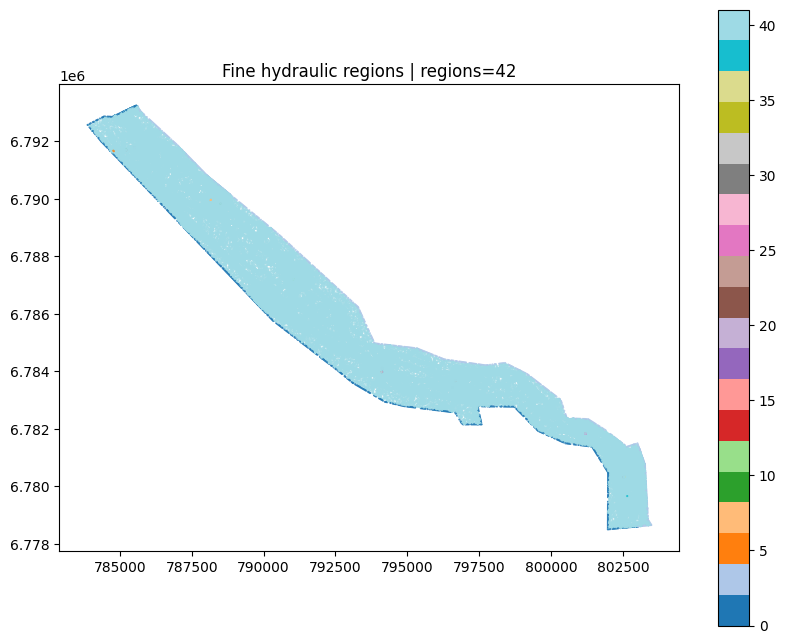

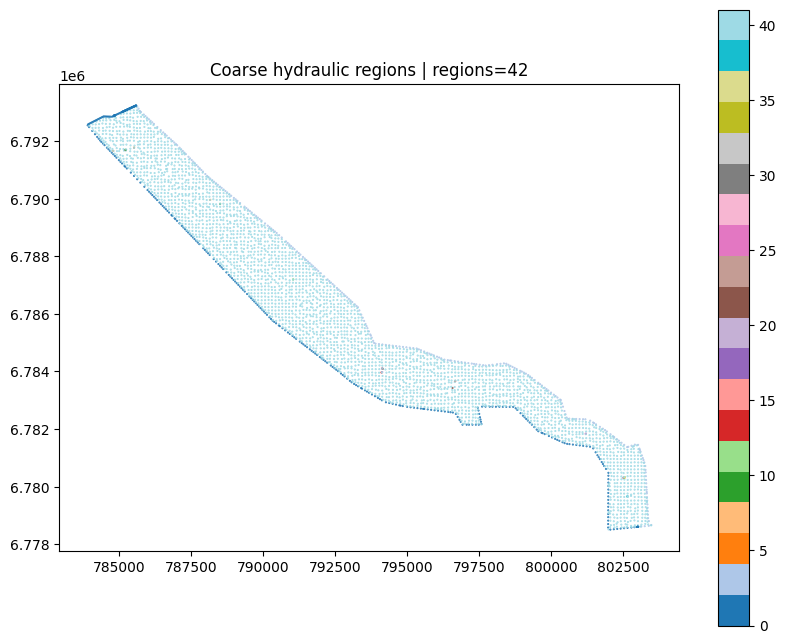

In [10]:
plot_regions(xy, coarse.region_id, 'Fine hydraulic regions')
plot_regions(coarse.xy, coarse.coarse_region_id, 'Coarse hydraulic regions')

## 9. Visualisation du support coarse

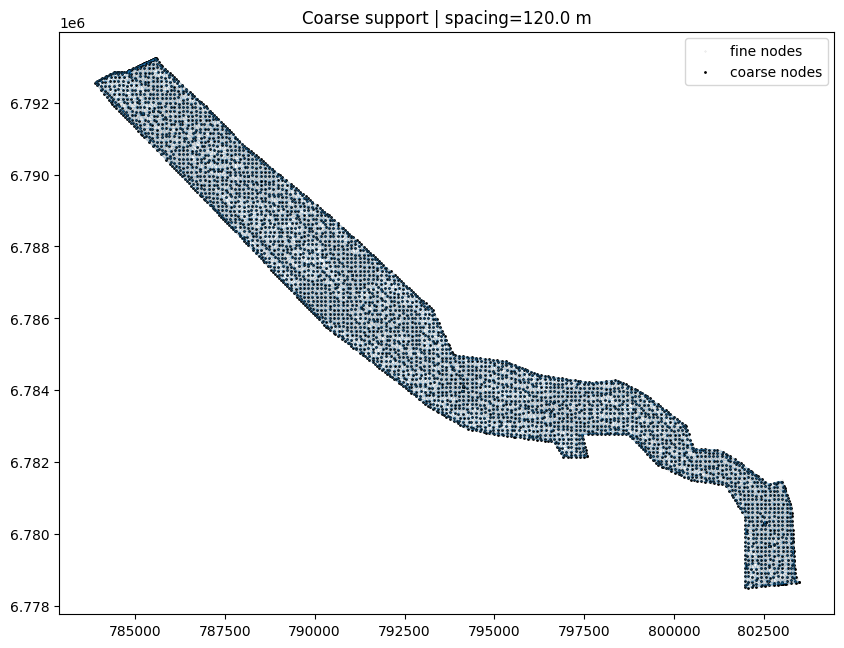

In [11]:
plot_coarse_support(
    fine_xy=xy,
    coarse_xy=coarse.xy,
    coarse_edges=coarse.undirected_edges,
    title=f'Coarse support | spacing={SPACING} m',
)

## 10. Triangulation  coarse

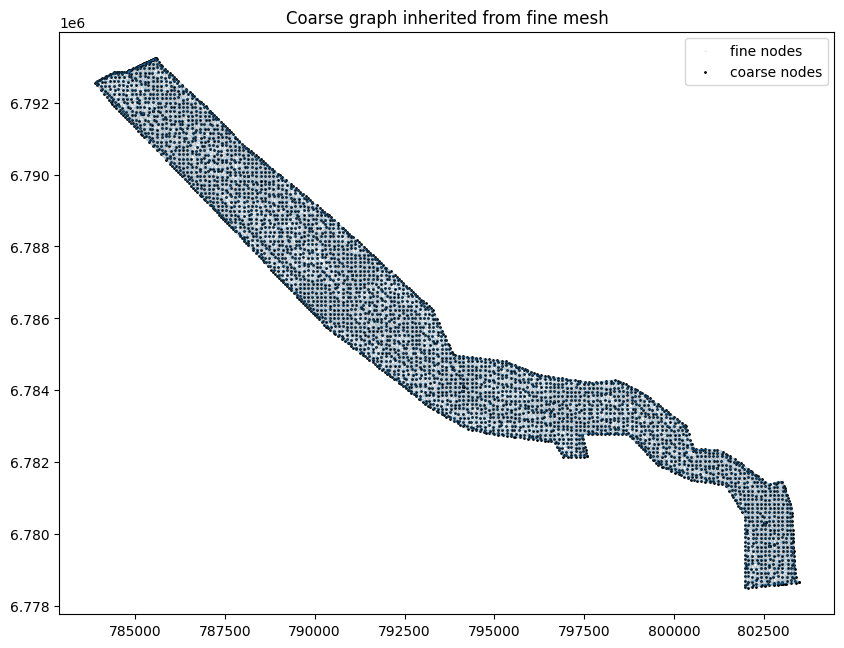

In [12]:
plot_coarse_support(
    fine_xy=xy,
    coarse_xy=coarse.xy,
    coarse_edges=coarse.undirected_edges,
    title='Coarse graph inherited from fine mesh',
)


## 11. Diagnostics des clusters

coarse nodes: 3769
mean cluster size: 83.18413372247281
median cluster size: 41.0
max cluster size: 1744
singletons: 243


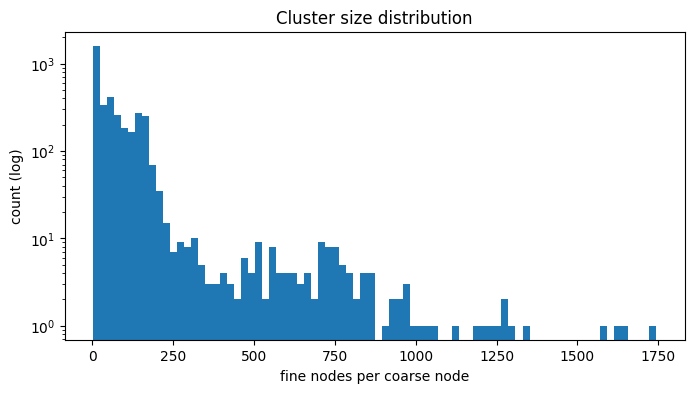

In [13]:
cluster_sizes = np.bincount(coarse.cluster)

print('coarse nodes:', len(cluster_sizes))
print('mean cluster size:', float(cluster_sizes.mean()))
print('median cluster size:', float(np.median(cluster_sizes)))
print('max cluster size:', int(cluster_sizes.max()))
print('singletons:', int((cluster_sizes == 1).sum()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cluster_sizes, bins=80, log=True)
ax.set_xlabel('fine nodes per coarse node')
ax.set_ylabel('count (log)')
ax.set_title('Cluster size distribution')
plt.show()

## 12. Projection de la topographie

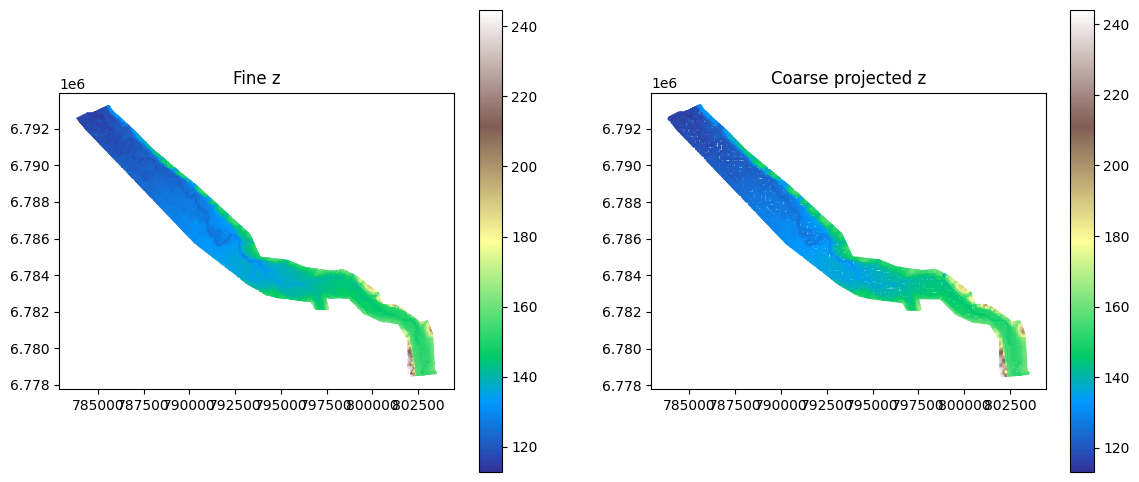

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

idx = sample_indices(len(xy), MAX_SCATTER_POINTS)
sc0 = axes[0].scatter(xy[idx, 0], xy[idx, 1], c=z[idx], s=0.2, cmap='terrain')
axes[0].set_aspect('equal')
axes[0].set_title('Fine z')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(coarse.xy[:, 0], coarse.xy[:, 1], c=coarse.z, s=2.0, cmap='terrain')
axes[1].set_aspect('equal')
axes[1].set_title('Coarse projected z')
plt.colorbar(sc1, ax=axes[1])

plt.show()

## 13. Export du maillage coarse en BIN

In [15]:
bin_path = write_coarse_bin(
    COARSE_BIN,
    coarse,
    overwrite=True,
)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NORMAL = 0  # même convention que dans ton code

xy = np.asarray(coarse.xy, dtype=float)
edges = np.asarray(coarse.undirected_edges, dtype=int)
boundary_type = np.asarray(coarse.boundary_type, dtype=int)

src = edges[:, 0]
dst = edges[:, 1]

edge_lengths = np.linalg.norm(xy[dst] - xy[src], axis=1)

boundary_node_mask = boundary_type != NORMAL
edge_touch_boundary = boundary_node_mask[src] | boundary_node_mask[dst]
edge_both_boundary = boundary_node_mask[src] & boundary_node_mask[dst]
edge_internal_only = (~boundary_node_mask[src]) & (~boundary_node_mask[dst])

print("nodes:", len(xy))
print("edges:", len(edges))
print("boundary nodes:", int(boundary_node_mask.sum()))
print("edges touching boundary:", int(edge_touch_boundary.sum()))
print("edges boundary-boundary:", int(edge_both_boundary.sum()))
print("edges fully internal:", int(edge_internal_only.sum()))


nodes: 3769
edges: 10609
boundary nodes: 670
edges touching boundary: 1878
edges boundary-boundary: 633
edges fully internal: 8731


In [17]:
def summarize_lengths(name, values):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return {
            "name": name,
            "count": 0,
            "min": np.nan,
            "p05": np.nan,
            "p25": np.nan,
            "median": np.nan,
            "p75": np.nan,
            "p95": np.nan,
            "max": np.nan,
        }
    q05, q25, q50, q75, q95 = np.percentile(values, [5, 25, 50, 75, 95])
    return {
        "name": name,
        "count": len(values),
        "min": values.min(),
        "p05": q05,
        "p25": q25,
        "median": q50,
        "p75": q75,
        "p95": q95,
        "max": values.max(),
    }

summary = pd.DataFrame([
    summarize_lengths("all edges", edge_lengths),
    summarize_lengths("touch boundary", edge_lengths[edge_touch_boundary]),
    summarize_lengths("boundary-boundary", edge_lengths[edge_both_boundary]),
    summarize_lengths("internal only", edge_lengths[edge_internal_only]),
])

display(summary.round(3))


,name,count,min,p05,p25,median,p75,p95,max
0,all edges,10609,2.688,56.852,103.787,123.094,153.929,188.437,256.485
1,touch boundary,1878,2.688,11.415,55.975,80.000,119.171,144.138,200.000
2,boundary-boundary,633,2.688,10.000,80.000,80.000,120.000,155.703,200.000
3,internal only,8731,35.459,83.129,111.712,129.198,160.034,191.343,256.485


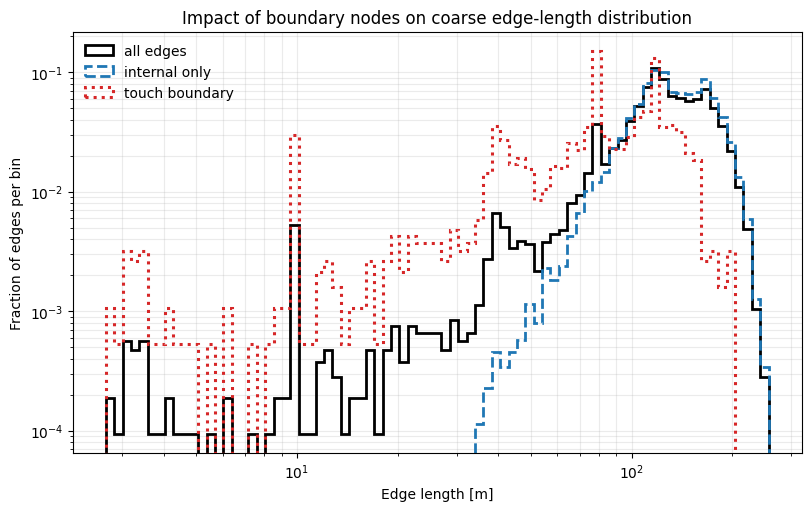

In [18]:
plot_sets = {
    "all edges": edge_lengths,
    "internal only": edge_lengths[edge_internal_only],
    "touch boundary": edge_lengths[edge_touch_boundary],
}

all_vals = np.concatenate([v for v in plot_sets.values() if len(v) > 0])
bins = np.geomspace(all_vals.min(), all_vals.max(), 80)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

styles = {
    "all edges": dict(color="black", linestyle="-", linewidth=2.0),
    "internal only": dict(color="#1f77b4", linestyle="--", linewidth=2.0),
    "touch boundary": dict(color="#d62728", linestyle=":", linewidth=2.2),
}

for name, vals in plot_sets.items():
    if len(vals) == 0:
        continue
    weights = np.full(len(vals), 1.0 / len(vals))
    ax.hist(
        vals,
        bins=bins,
        weights=weights,
        histtype="step",
        label=name,
        **styles[name],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Edge length [m]")
ax.set_ylabel("Fraction of edges per bin")
ax.set_title("Impact of boundary nodes on coarse edge-length distribution")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)
plt.show()


In [19]:
left_threshold = 10.0  # à ajuster si tu veux, par ex 5, 10, 20 m

left_all = edge_lengths <= left_threshold
left_internal = edge_internal_only & (edge_lengths <= left_threshold)
left_boundary = edge_touch_boundary & (edge_lengths <= left_threshold)

print(f"Edges <= {left_threshold} m")
print("all:", int(left_all.sum()), f"({100 * left_all.mean():.2f}%)")
print("internal only:", int(left_internal.sum()), f"({100 * left_internal.sum() / len(edge_lengths):.2f}% of all edges)")
print("touch boundary:", int(left_boundary.sum()), f"({100 * left_boundary.sum() / len(edge_lengths):.2f}% of all edges)")


Edges <= 10.0 m
all: 73 (0.69%)
internal only: 0 (0.00% of all edges)
touch boundary: 73 (0.69% of all edges)


In [20]:
k = 30  # nombre de plus petites arêtes à inspecter

order = np.argsort(edge_lengths)[:k]

df_small = pd.DataFrame({
    "edge_id": order,
    "src": src[order],
    "dst": dst[order],
    "length": edge_lengths[order],
    "src_boundary_type": boundary_type[src[order]],
    "dst_boundary_type": boundary_type[dst[order]],
    "touch_boundary": edge_touch_boundary[order],
    "src_x": xy[src[order], 0],
    "src_y": xy[src[order], 1],
    "dst_x": xy[dst[order], 0],
    "dst_y": xy[dst[order], 1],
})

display(df_small.round(3))


,edge_id,src,dst,length,src_boundary_type,dst_boundary_type,touch_boundary,src_x,src_y,dst_x,dst_y
0,10514,3665,3763,2.688,1,1,True,784811.726,6792884.016,784809.290,6792882.880
1,10502,3659,3667,2.791,2,2,True,803015.885,6778600.148,803013.107,6778599.873
2,209,63,64,2.855,3,0,True,784782.279,6791662.150,784785.035,6791661.406
3,10598,3749,3750,3.130,2,2,True,802997.166,6778598.292,802994.051,6778597.983
4,10596,3747,3748,3.170,2,2,True,803003.584,6778598.928,803000.429,6778598.616
5,10501,3659,3666,3.171,2,2,True,803015.885,6778600.148,803019.040,6778600.461
6,10513,3665,3758,3.171,1,1,True,784811.726,6792884.016,784814.600,6792885.356
7,10595,3746,3747,3.180,2,2,True,803006.748,6778599.242,803003.584,6778598.928
8,10556,3705,3746,3.190,2,2,True,803009.923,6778599.557,803006.748,6778599.242
9,10515,3667,3705,3.200,2,2,True,803013.107,6778599.873,803009.923,6778599.557


In [21]:
topo_node_mask = np.asarray(coarse.topo_barrier_node_mask, dtype=bool)

edge_touch_topo = topo_node_mask[src] | topo_node_mask[dst]
edge_internal_non_topo = (
    (~boundary_node_mask[src]) & (~boundary_node_mask[dst]) &
    (~topo_node_mask[src]) & (~topo_node_mask[dst])
)

summary_topo = pd.DataFrame([
    summarize_lengths("all edges", edge_lengths),
    summarize_lengths("touch boundary", edge_lengths[edge_touch_boundary]),
    summarize_lengths("touch topo", edge_lengths[edge_touch_topo]),
    summarize_lengths("internal non-topo", edge_lengths[edge_internal_non_topo]),
])

display(summary_topo.round(3))


,name,count,min,p05,p25,median,p75,p95,max
0,all edges,10609,2.688,56.852,103.787,123.094,153.929,188.437,256.485
1,touch boundary,1878,2.688,11.415,55.975,80.000,119.171,144.138,200.000
2,touch topo,351,10.000,64.788,103.742,123.296,155.673,181.505,223.304
3,internal non-topo,8445,35.459,83.358,111.732,129.264,160.136,191.521,256.485


In [22]:
import numpy as np
import pandas as pd

cluster = np.asarray(coarse.cluster, dtype=int)
counts = np.bincount(cluster)

summary = pd.DataFrame([{
    "n_clusters": len(counts),
    "fine_nodes": int(counts.sum()),
    "min_nodes_per_cluster": int(counts.min()),
    "p05": float(np.percentile(counts, 5)),
    "p25": float(np.percentile(counts, 25)),
    "median": float(np.percentile(counts, 50)),
    "p75": float(np.percentile(counts, 75)),
    "p95": float(np.percentile(counts, 95)),
    "max_nodes_per_cluster": int(counts.max()),
    "singletons": int((counts == 1).sum()),
    "singleton_fraction": float((counts == 1).mean()),
}])

display(summary.round(3))


,n_clusters,fine_nodes,min_nodes_per_cluster,p05,p25,median,p75,p95,max_nodes_per_cluster,singletons,singleton_fraction
0,3769,313521,1,1.0,8.0,41.0,114.0,217.6,1744,243,0.064


In [23]:
import numpy as np
import pandas as pd

xy = np.asarray(coarse.xy, dtype=float)
edges = np.asarray(coarse.undirected_edges, dtype=int)

src = edges[:, 0]
dst = edges[:, 1]
edge_lengths = np.linalg.norm(xy[dst] - xy[src], axis=1)

cluster_sizes = np.bincount(np.asarray(coarse.cluster, dtype=int))
src_size = cluster_sizes[src]
dst_size = cluster_sizes[dst]
min_side_size = np.minimum(src_size, dst_size)

bins = [0, 1, 2, 5, 10, 20, 50, 100, np.inf]
labels = ["1", "2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"]

df = pd.DataFrame({
    "edge_length": edge_lengths,
    "min_side_size": min_side_size,
})

df["size_class"] = pd.cut(
    df["min_side_size"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True,
)

stats = df.groupby("size_class")["edge_length"].agg(
    count="count",
    min="min",
    p05=lambda x: np.percentile(x, 5),
    p25=lambda x: np.percentile(x, 25),
    median=lambda x: np.percentile(x, 50),
    p75=lambda x: np.percentile(x, 75),
    p95=lambda x: np.percentile(x, 95),
    max="max",
)

display(stats.round(3))



/tmp/ipykernel_3396821/1916101586.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("size_class")["edge_length"].agg(


,count,min,p05,p25,median,p75,p95,max
size_class,,,,,,,,
1,715,2.688,10.000,41.397,80.000,88.698,120.000,155.982
2,476,10.248,40.341,72.967,80.000,117.002,137.498,189.832
3-5,1056,11.528,41.376,84.166,113.910,129.074,160.000,201.664
6-10,1826,6.080,90.145,119.229,140.128,164.474,196.414,226.167
11-20,1138,4.559,74.307,110.947,135.865,162.734,196.982,230.366
21-50,1613,3.288,72.071,102.943,127.640,159.945,198.466,256.485
51-100,1754,3.492,87.619,110.627,128.608,156.460,188.190,226.937
100+,2031,2.855,93.846,114.417,123.652,161.179,179.661,219.640
